# 05 — Transfer learning with ResNet18

Same data, same validation set, same training loop as notebook 04. The model
is what changes.

**The idea:** ResNet18 was trained on ImageNet — 1.2M photographs across 1000
categories. In learning that, its early layers became general-purpose edge,
texture and shape detectors. Those features transfer to brain MRI even though
ImageNet contains no medical images at all, because low-level visual structure
is low-level visual structure.

You keep the pretrained feature extractor and replace only the final
classification layer.

**Two stages:**
1. Freeze the backbone, train only the new head. The head starts random, and
   letting large random gradients flow back would damage the pretrained
   weights before they've been useful.
2. Unfreeze and fine-tune everything at a much lower learning rate, letting
   the features adapt to MRI specifically.

**Still do not touch the test set.** Model selection happens on validation.

## 1. Setup

In [1]:
import json, time
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import f1_score
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)

d = np.load("data/final_dataset.npz", allow_pickle=True)
X_train, y_train = d["X_train"], d["y_train"]
X_val,   y_val   = d["X_val"],   d["y_val"]
CLASSES = [str(c) for c in d["classes"]]

print(f"train {X_train.shape}   val {X_val.shape}")

device: mps
train (4803, 224, 224)   val (797, 224, 224)


## 2. Transforms — two changes from notebook 04

**Three channels.** ResNet18's first convolution expects RGB input. Our
images are grayscale, so replicate the single channel three times. The three
channels are identical — this is a shape fix, not added information.

**ImageNet normalization statistics.** This one matters more than it looks.
The pretrained weights were tuned for inputs distributed the way ImageNet
photos are after normalizing with ImageNet's mean and std. Feed them data
normalized with *our* dataset statistics and every pretrained filter sees a
distribution it wasn't calibrated for — which quietly destroys most of the
benefit of transfer learning.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # 1 channel -> 3 identical
    transforms.RandomRotation(12),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class BrainMRI(Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        img = Image.fromarray((self.X[i] * 255).astype(np.uint8))
        return self.transform(img), int(self.y[i])


BATCH = 32
train_dl = DataLoader(BrainMRI(X_train, y_train, train_tf), batch_size=BATCH,
                      shuffle=True, num_workers=0, drop_last=True)
val_dl   = DataLoader(BrainMRI(X_val, y_val, eval_tf), batch_size=BATCH,
                      shuffle=False, num_workers=0)

print(f"batches: train {len(train_dl)}, val {len(val_dl)}")

xb, yb = next(iter(train_dl))
print("tensor shape:", tuple(xb.shape), "<- 3 channels now")

batches: train 150, val 25
tensor shape: (32, 3, 224, 224) <- 3 channels now


## 3. Build the model

`weights=ResNet18_Weights.DEFAULT` downloads the pretrained weights (~45 MB)
on first use and caches them in `~/.cache/torch/`.

ResNet18's final layer is `fc`, mapping 512 features to ImageNet's 1000
categories. Replace it with a fresh `Linear(512, 4)`. The new layer starts
with random weights; everything before it starts pretrained.

In [3]:
def build_resnet(n_classes=4, freeze_backbone=True):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        # requires_grad=False means these parameters get no gradients and
        # the optimizer will not update them.
        for p in m.parameters():
            p.requires_grad = False

    # Replacing fc AFTER freezing means the new layer keeps requires_grad=True
    # (the default for a freshly created layer), so only the head trains.
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m


model = build_resnet(len(CLASSES), freeze_backbone=True).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total parameters    : {total:,}")
print(f"trainable (stage 1) : {trainable:,}  <- just the new head")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sanaataneja/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.44MB/s]


total parameters    : 11,178,564
trainable (stage 1) : 2,052  <- just the new head


## 4. Training helper

Identical to notebook 04 — repeated here so this notebook runs standalone.

In [4]:
def run_epoch(model, loader, optimizer=None):
    """One pass over a loader. optimizer=None means evaluate."""
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, preds, trues = 0.0, [], []
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.append(out.argmax(1).cpu())
            trues.append(yb.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return (total_loss / len(trues),
            (preds == trues).mean(),
            f1_score(trues, preds, average="macro"))


def train(model, epochs, lr, tag, history, weight_decay=1e-4, patience=8):
    """Train for `epochs`, checkpointing on best val macro-F1."""
    # Only pass parameters that actually require gradients — passing frozen
    # ones wastes optimizer state and is a common source of confusion.
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_f1, best_epoch, stale = 0.0, 0, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, train_dl, opt)
        va = run_epoch(model, val_dl)
        sched.step()

        for k, v in zip(["tr_loss", "tr_acc", "tr_f1"], tr):
            history[k].append(v)
        for k, v in zip(["va_loss", "va_acc", "va_f1"], va):
            history[k].append(v)

        flag = ""
        if va[2] > best_f1:
            best_f1, best_epoch, stale = va[2], ep, 0
            torch.save(model.state_dict(), f"checkpoints/{tag}.pt")
            flag = "  <- best"
        else:
            stale += 1

        print(f"ep {ep:>2}  tr_loss {tr[0]:.3f} va_loss {va[0]:.3f}  "
              f"va_acc {va[1]:.3f} va_f1 {va[2]:.3f}  "
              f"({time.time()-t0:.0f}s){flag}")

        if stale >= patience:
            print(f"Early stop — no improvement in {patience} epochs.")
            break

    return best_f1, best_epoch

## 5. Stage 1 — head only

Short and fast. Only 2,052 parameters are training, so this converges quickly.
A higher learning rate (1e-3) is fine because the pretrained weights are
protected — nothing can damage them while they're frozen.

In [6]:
Path("checkpoints").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

history = defaultdict(list)
s1_f1, s1_ep = train(model, epochs=8, lr=1e-3,
                     tag="resnet18_stage1", history=history)
print(f"\nStage 1 best val macro-F1: {s1_f1:.3f} (epoch {s1_ep})")

ep  1  tr_loss 0.399 va_loss 0.386  va_acc 0.862 va_f1 0.865  (18s)  <- best
ep  2  tr_loss 0.391 va_loss 0.388  va_acc 0.862 va_f1 0.866  (18s)  <- best
ep  3  tr_loss 0.363 va_loss 0.384  va_acc 0.858 va_f1 0.863  (17s)
ep  4  tr_loss 0.353 va_loss 0.369  va_acc 0.862 va_f1 0.868  (17s)  <- best
ep  5  tr_loss 0.343 va_loss 0.366  va_acc 0.861 va_f1 0.863  (16s)
ep  6  tr_loss 0.341 va_loss 0.370  va_acc 0.862 va_f1 0.865  (30s)
ep  7  tr_loss 0.325 va_loss 0.357  va_acc 0.875 va_f1 0.877  (44s)  <- best
ep  8  tr_loss 0.325 va_loss 0.351  va_acc 0.875 va_f1 0.879  (18s)  <- best

Stage 1 best val macro-F1: 0.879 (epoch 8)


## 6. Stage 2 — fine-tune

Unfreeze `layer4` (the deepest conv block) plus the head, and train at 1e-4 —
ten times lower.

**Why only layer4?** Early layers detect edges and textures that are already
correct for any image. Deep layers encode ImageNet-specific concepts, and
those are the ones worth adapting to MRI. Unfreezing everything also works,
but risks disturbing good general features and takes longer.

**Why the lower learning rate?** The pretrained weights are already near a
good solution. Large steps would knock them out of it — that's called
catastrophic forgetting.

In [7]:
for name, param in model.named_parameters():
    # startswith covers layer4.0.conv1.weight, layer4.1.bn2.bias, etc.
    param.requires_grad = name.startswith("layer4") or name.startswith("fc")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable (stage 2): {trainable:,}\n")

s2_f1, s2_ep = train(model, epochs=20, lr=1e-4,
                     tag="resnet18_finetuned", history=history)
print(f"\nStage 2 best val macro-F1: {s2_f1:.3f} (epoch {s2_ep})")

trainable (stage 2): 8,395,780

ep  1  tr_loss 0.255 va_loss 0.233  va_acc 0.921 va_f1 0.924  (25s)  <- best
ep  2  tr_loss 0.126 va_loss 0.202  va_acc 0.944 va_f1 0.944  (24s)  <- best
ep  3  tr_loss 0.089 va_loss 0.192  va_acc 0.954 va_f1 0.955  (25s)  <- best
ep  4  tr_loss 0.057 va_loss 0.208  va_acc 0.955 va_f1 0.956  (24s)  <- best
ep  5  tr_loss 0.045 va_loss 0.248  va_acc 0.942 va_f1 0.945  (24s)
ep  6  tr_loss 0.047 va_loss 0.239  va_acc 0.956 va_f1 0.956  (26s)  <- best
ep  7  tr_loss 0.033 va_loss 0.157  va_acc 0.962 va_f1 0.963  (24s)  <- best
ep  8  tr_loss 0.023 va_loss 0.163  va_acc 0.961 va_f1 0.962  (22s)
ep  9  tr_loss 0.022 va_loss 0.160  va_acc 0.970 va_f1 0.970  (22s)  <- best
ep 10  tr_loss 0.014 va_loss 0.147  va_acc 0.967 va_f1 0.968  (22s)
ep 11  tr_loss 0.018 va_loss 0.186  va_acc 0.962 va_f1 0.963  (23s)
ep 12  tr_loss 0.013 va_loss 0.145  va_acc 0.970 va_f1 0.971  (25s)  <- best
ep 13  tr_loss 0.009 va_loss 0.170  va_acc 0.961 va_f1 0.962  (25s)
ep 14  tr_lo

## 7. Curves

The vertical line marks the stage boundary. Expect a visible jump there —
unfreezing layer4 gives the model far more capacity to fit your data.

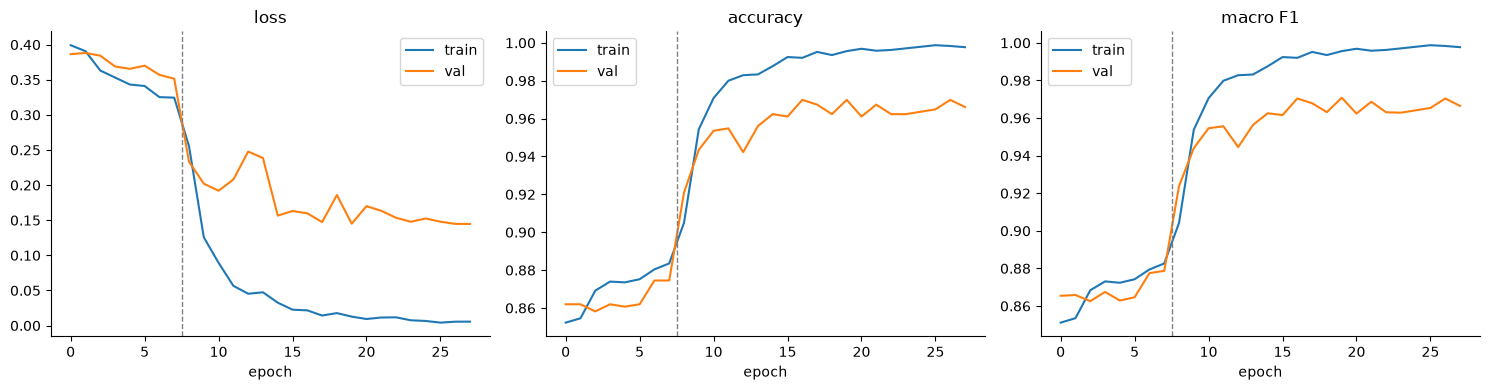

gray dashed = stage 1 -> stage 2 boundary


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
split_at = 8   # epochs in stage 1

for ax, (a, b, name) in zip(axes, [("tr_loss", "va_loss", "loss"),
                                   ("tr_acc", "va_acc", "accuracy"),
                                   ("tr_f1", "va_f1", "macro F1")]):
    ax.plot(history[a], label="train")
    ax.plot(history[b], label="val")
    ax.axvline(split_at - 0.5, color="gray", ls="--", lw=1)
    ax.set_xlabel("epoch"); ax.set_title(name); ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig("figures/resnet18_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("gray dashed = stage 1 -> stage 2 boundary")

The train/val loss gap is large. Train loss fell to 0.006 while val loss plateaued around 0.145, so a 24× ratio. The model has essentially memorized the training set. Val accuracy stayed stable rather than degrading, so it's benign, but it means there's nothing more to extract from longer training.

## 8. Log and compare

The comparison that decides which model goes to the test set.

In [12]:
import csv

best_f1 = max(s1_f1, s2_f1)
row = {
    "model": "ResNet18 pretrained",
    "lr": "1e-3 head / 1e-4 finetune",
    "weight_decay": 1e-4,
    "batch": BATCH,
    "augment": "rot12+hflip+jitter",
    "epochs_run": len(history["tr_loss"]),
    "best_epoch": s2_ep if s2_f1 >= s1_f1 else s1_ep,
    "best_val_f1": round(best_f1, 4),
    "best_val_acc": round(max(history["va_acc"]), 4),
    "shape_control": "",
    "notes": "two-stage freeze then finetune layer4",
}

log_path = Path("results/experiments.csv")
write_header = not log_path.exists()
with open(log_path, "a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(row))
    if write_header:
        w.writeheader()
    w.writerow(row)

with open("results/resnet18_history.json", "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in history.items()}, f)

print(f"ResNet18 best val macro-F1: {best_f1:.4f}")
print("\nWhen compared against the CNN model, the ResNet18 model has a slightly higher validation macro-F1 \n score and wins mostly on convenience instead of merit.")

ResNet18 best val macro-F1: 0.9708

When compared against the CNN model, the ResNet18 model has a slightly higher validation macro-F1 
 score and wins mostly on convenience instead of merit.


## Next

`06_final_evaluation.ipynb` — load the winning checkpoint, run the test set
exactly once, and produce the confusion matrix, per-class report, error
analysis, and the control table.

Pay particular attention to glioma vs meningioma. That pair has the least
available shortcut, so their mutual confusion rate says more about genuine
feature learning than the headline accuracy does.